# Dental Clinic Operations Analytics - Exploratory Data Analysis

State the business question before running code. All records are synthetic.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data directory: {DATA_DIR}")
print(f"Data directory exists: {DATA_DIR.exists()}")

Project root: C:\Users\user\Hamed Projects\dental-clinic-operations-analytics
Raw data directory: C:\Users\user\Hamed Projects\dental-clinic-operations-analytics\data\raw
Data directory exists: True


## 1. Load and validate the datasets
Check shape, data types, missing values, duplicates, and key integrity.

In [4]:
patients = pd.read_csv(
    DATA_DIR / "patients.csv",
    parse_dates=["registered_at"],
)

dentists = pd.read_csv(
    DATA_DIR / "dentists.csv",
    parse_dates=["start_date", "end_date"],
)

appointments = pd.read_csv(
    DATA_DIR / "appointments.csv",
    parse_dates=[
        "booked_at",
        "scheduled_start_at",
        "status_updated_at",
        "check_in_at",
        "chair_start_at",
        "chair_end_at",
        "checkout_at",
    ],
)

procedure_catalog = pd.read_csv(
    DATA_DIR / "procedure_catalog.csv",
)

appointment_procedures = pd.read_csv(
    DATA_DIR / "appointment_procedures.csv",
)

treatment_plans = pd.read_csv(
    DATA_DIR / "treatment_plans.csv",
    parse_dates=["proposed_at", "valid_until"],
)

treatment_plan_items = pd.read_csv(
    DATA_DIR / "treatment_plan_items.csv",
    parse_dates=["decision_at"],
)

payments = pd.read_csv(
    DATA_DIR / "payments.csv",
    parse_dates=["received_at"],
)

payment_allocations = pd.read_csv(
    DATA_DIR / "payment_allocations.csv",
)

datasets = {
    "patients": patients,
    "dentists": dentists,
    "appointments": appointments,
    "procedure_catalog": procedure_catalog,
    "appointment_procedures": appointment_procedures,
    "treatment_plans": treatment_plans,
    "treatment_plan_items": treatment_plan_items,
    "payments": payments,
    "payment_allocations": payment_allocations,
}

dataset_shapes = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": len(dataframe),
            "columns": len(dataframe.columns),
        }
        for name, dataframe in datasets.items()
    ]
)

dataset_shapes

,dataset,rows,columns
0,patients,2000,9
1,dentists,7,7
2,appointments,8000,17
3,procedure_catalog,24,7
4,appointment_procedures,8378,10
5,treatment_plans,1775,7
6,treatment_plan_items,3596,11
7,payments,7973,10
8,payment_allocations,9616,4


In [5]:
data_quality_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": len(dataframe),
            "columns": len(dataframe.columns),
            "duplicate_rows": int(dataframe.duplicated().sum()),
            "missing_cells": int(dataframe.isna().sum().sum()),
            "columns_with_missing_values": int(
                dataframe.isna().any().sum()
            ),
        }
        for name, dataframe in datasets.items()
    ]
)

data_quality_summary

,dataset,rows,columns,duplicate_rows,missing_cells,columns_with_missing_values
0,patients,2000,9,0,0,0
1,dentists,7,7,0,6,1
2,appointments,8000,17,0,22597,6
3,procedure_catalog,24,7,0,0,0
4,appointment_procedures,8378,10,0,13130,2
5,treatment_plans,1775,7,0,0,0
6,treatment_plan_items,3596,11,0,1375,2
7,payments,7973,10,0,7796,1
8,payment_allocations,9616,4,0,0,0


In [7]:
missing_by_column = pd.concat(
    [
        dataframe.isna()
        .sum()
        .rename("missing_count")
        .to_frame()
        .assign(
            dataset=name,
            missing_percentage=lambda frame: (
                100
                * frame["missing_count"]
                / len(dataframe)
            ).round(2),
        )
        .reset_index(names="column")
        for name, dataframe in datasets.items()
    ],
    ignore_index=True,
)

missing_by_column = (
    missing_by_column.loc[
        missing_by_column["missing_count"] > 0
    ]
    .sort_values(
        ["dataset", "missing_count"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

print(missing_by_column.to_string(index=False))

                         column  missing_count                dataset  missing_percentage
                   plan_item_id           8265 appointment_procedures               98.65
                     tooth_code           4865 appointment_procedures               58.07
rescheduled_from_appointment_id           7579           appointments               94.74
           status_change_reason           6762           appointments               84.52
                    check_in_at           2064           appointments               25.80
                 chair_start_at           2064           appointments               25.80
                   chair_end_at           2064           appointments               25.80
                    checkout_at           2064           appointments               25.80
                       end_date              6               dentists               85.71
                          notes           7796               payments               97.78
          

In [8]:
appointment_timing_checks = pd.Series(
    {
        "completed_appointments": int(
            appointments["status"].eq("completed").sum()
        ),
        "non_completed_appointments": int(
            appointments["status"].ne("completed").sum()
        ),
        "completed_missing_check_in": int(
            appointments.loc[
                appointments["status"].eq("completed"),
                "check_in_at",
            ].isna().sum()
        ),
        "completed_missing_chair_start": int(
            appointments.loc[
                appointments["status"].eq("completed"),
                "chair_start_at",
            ].isna().sum()
        ),
        "completed_missing_chair_end": int(
            appointments.loc[
                appointments["status"].eq("completed"),
                "chair_end_at",
            ].isna().sum()
        ),
        "completed_missing_checkout": int(
            appointments.loc[
                appointments["status"].eq("completed"),
                "checkout_at",
            ].isna().sum()
        ),
        "non_completed_with_any_clinical_timestamp": int(
            appointments.loc[
                appointments["status"].ne("completed"),
                [
                    "check_in_at",
                    "chair_start_at",
                    "chair_end_at",
                    "checkout_at",
                ],
            ]
            .notna()
            .any(axis=1)
            .sum()
        ),
    },
    name="count",
)

appointment_timing_checks

completed_appointments                       5936
non_completed_appointments                   2064
completed_missing_check_in                      0
completed_missing_chair_start                   0
completed_missing_chair_end                     0
completed_missing_checkout                      0
non_completed_with_any_clinical_timestamp       0
Name: count, dtype: int64

In [10]:
primary_key_checks = pd.DataFrame(
    [
        {
            "dataset": "patients",
            "primary_key": "patient_id",
            "missing_keys": int(
                patients["patient_id"].isna().sum()
            ),
            "duplicate_keys": int(
                patients["patient_id"].duplicated().sum()
            ),
        },
        {
            "dataset": "dentists",
            "primary_key": "dentist_id",
            "missing_keys": int(
                dentists["dentist_id"].isna().sum()
            ),
            "duplicate_keys": int(
                dentists["dentist_id"].duplicated().sum()
            ),
        },
        {
            "dataset": "appointments",
            "primary_key": "appointment_id",
            "missing_keys": int(
                appointments["appointment_id"].isna().sum()
            ),
            "duplicate_keys": int(
                appointments["appointment_id"].duplicated().sum()
            ),
        },
        {
            "dataset": "procedure_catalog",
            "primary_key": "procedure_code",
            "missing_keys": int(
                procedure_catalog["procedure_code"].isna().sum()
            ),
            "duplicate_keys": int(
                procedure_catalog[
                    "procedure_code"
                ].duplicated().sum()
            ),
        },
        {
            "dataset": "appointment_procedures",
            "primary_key": "appointment_procedure_id",
            "missing_keys": int(
                appointment_procedures[
                    "appointment_procedure_id"
                ].isna().sum()
            ),
            "duplicate_keys": int(
                appointment_procedures[
                    "appointment_procedure_id"
                ].duplicated().sum()
            ),
        },
        {
            "dataset": "treatment_plans",
            "primary_key": "plan_id",
            "missing_keys": int(
                treatment_plans["plan_id"].isna().sum()
            ),
            "duplicate_keys": int(
                treatment_plans["plan_id"].duplicated().sum()
            ),
        },
        {
            "dataset": "treatment_plan_items",
            "primary_key": "plan_item_id",
            "missing_keys": int(
                treatment_plan_items[
                    "plan_item_id"
                ].isna().sum()
            ),
            "duplicate_keys": int(
                treatment_plan_items[
                    "plan_item_id"
                ].duplicated().sum()
            ),
        },
        {
            "dataset": "payments",
            "primary_key": "payment_id",
            "missing_keys": int(
                payments["payment_id"].isna().sum()
            ),
            "duplicate_keys": int(
                payments["payment_id"].duplicated().sum()
            ),
        },
        {
            "dataset": "payment_allocations",
            "primary_key": "allocation_id",
            "missing_keys": int(
                payment_allocations[
                    "allocation_id"
                ].isna().sum()
            ),
            "duplicate_keys": int(
                payment_allocations[
                    "allocation_id"
                ].duplicated().sum()
            ),
        },
    ]
)

primary_key_checks

,dataset,primary_key,missing_keys,duplicate_keys
0,patients,patient_id,0,0
1,dentists,dentist_id,0,0
2,appointments,appointment_id,0,0
3,procedure_catalog,procedure_code,0,0
4,appointment_procedures,appointment_procedure_id,0,0
5,treatment_plans,plan_id,0,0
6,treatment_plan_items,plan_item_id,0,0
7,payments,payment_id,0,0
8,payment_allocations,allocation_id,0,0


In [14]:
def count_orphan_keys(
    child_dataframe,
    child_column,
    parent_dataframe,
    parent_column,
):
    child_values = child_dataframe[
        child_column
    ].dropna()

    return int(
        (
            ~child_values.isin(
                parent_dataframe[parent_column]
            )
        ).sum()
    )


foreign_key_checks = pd.DataFrame(
    [
        {
            "relationship": "appointments.patient_id -> patients.patient_id",
            "orphan_keys": count_orphan_keys(
                appointments,
                "patient_id",
                patients,
                "patient_id",
            ),
        },
        {
            "relationship": "appointments.dentist_id -> dentists.dentist_id",
            "orphan_keys": count_orphan_keys(
                appointments,
                "dentist_id",
                dentists,
                "dentist_id",
            ),
        },
        {
            "relationship": (
                "appointments.rescheduled_from_appointment_id "
                "-> appointments.appointment_id"
            ),
            "orphan_keys": count_orphan_keys(
                appointments,
                "rescheduled_from_appointment_id",
                appointments,
                "appointment_id",
            ),
        },
        {
            "relationship": (
                "appointment_procedures.appointment_id "
                "-> appointments.appointment_id"
            ),
            "orphan_keys": count_orphan_keys(
                appointment_procedures,
                "appointment_id",
                appointments,
                "appointment_id",
            ),
        },
        {
            "relationship": (
                "appointment_procedures.plan_item_id "
                "-> treatment_plan_items.plan_item_id"
            ),
            "orphan_keys": count_orphan_keys(
                appointment_procedures,
                "plan_item_id",
                treatment_plan_items,
                "plan_item_id",
            ),
        },
        {
            "relationship": (
                "appointment_procedures.procedure_code "
                "-> procedure_catalog.procedure_code"
            ),
            "orphan_keys": count_orphan_keys(
                appointment_procedures,
                "procedure_code",
                procedure_catalog,
                "procedure_code",
            ),
        },
        {
            "relationship": (
                "treatment_plans.patient_id "
                "-> patients.patient_id"
            ),
            "orphan_keys": count_orphan_keys(
                treatment_plans,
                "patient_id",
                patients,
                "patient_id",
            ),
        },
        {
            "relationship": (
                "treatment_plans.proposed_by_dentist_id "
                "-> dentists.dentist_id"
            ),
            "orphan_keys": count_orphan_keys(
                treatment_plans,
                "proposed_by_dentist_id",
                dentists,
                "dentist_id",
            ),
        },
        {
            "relationship": (
                "treatment_plans.source_appointment_id "
                "-> appointments.appointment_id"
            ),
            "orphan_keys": count_orphan_keys(
                treatment_plans,
                "source_appointment_id",
                appointments,
                "appointment_id",
            ),
        },
        {
            "relationship": (
                "treatment_plan_items.plan_id "
                "-> treatment_plans.plan_id"
            ),
            "orphan_keys": count_orphan_keys(
                treatment_plan_items,
                "plan_id",
                treatment_plans,
                "plan_id",
            ),
        },
        {
            "relationship": (
                "treatment_plan_items.procedure_code "
                "-> procedure_catalog.procedure_code"
            ),
            "orphan_keys": count_orphan_keys(
                treatment_plan_items,
                "procedure_code",
                procedure_catalog,
                "procedure_code",
            ),
        },
        {
            "relationship": (
                "payments.patient_id "
                "-> patients.patient_id"
            ),
            "orphan_keys": count_orphan_keys(
                payments,
                "patient_id",
                patients,
                "patient_id",
            ),
        },
        {
            "relationship": (
                "payment_allocations.payment_id "
                "-> payments.payment_id"
            ),
            "orphan_keys": count_orphan_keys(
                payment_allocations,
                "payment_id",
                payments,
                "payment_id",
            ),
        },
        {
            "relationship": (
                "payment_allocations.appointment_procedure_id "
                "-> appointment_procedures.appointment_procedure_id"
            ),
            "orphan_keys": count_orphan_keys(
                payment_allocations,
                "appointment_procedure_id",
                appointment_procedures,
                "appointment_procedure_id",
            ),
        },
    ]
)

print(foreign_key_checks.to_string(index=False))

                                                                                   relationship  orphan_keys
                                                 appointments.patient_id -> patients.patient_id            0
                                                 appointments.dentist_id -> dentists.dentist_id            0
                    appointments.rescheduled_from_appointment_id -> appointments.appointment_id            0
                           appointment_procedures.appointment_id -> appointments.appointment_id            0
                       appointment_procedures.plan_item_id -> treatment_plan_items.plan_item_id            0
                      appointment_procedures.procedure_code -> procedure_catalog.procedure_code            0
                                              treatment_plans.patient_id -> patients.patient_id            0
                                  treatment_plans.proposed_by_dentist_id -> dentists.dentist_id            0
                   

## 2. Define the first five management questions
1. What is the overall appointment status distribution, including the no-show rate?
2. Does sending a reminder correspond to a lower no-show rate in this synthetic dataset?
3. Which weekdays have the highest appointment non-completion rates?
4. Which procedure groups generate the highest revenue per chair hour?
5. How does treatment-plan item acceptance vary by insurance type?


In [15]:
appointment_status_summary = (
    appointments["status"]
    .value_counts(dropna=False)
    .rename_axis("status")
    .reset_index(name="appointment_count")
)

appointment_status_summary["appointment_percentage"] = (
    100
    * appointment_status_summary["appointment_count"]
    / len(appointments)
).round(2)

appointment_status_summary

,status,appointment_count,appointment_percentage
0,completed,5936,74.20
1,no_show,826,10.32
2,cancelled,816,10.20
3,rescheduled,422,5.28


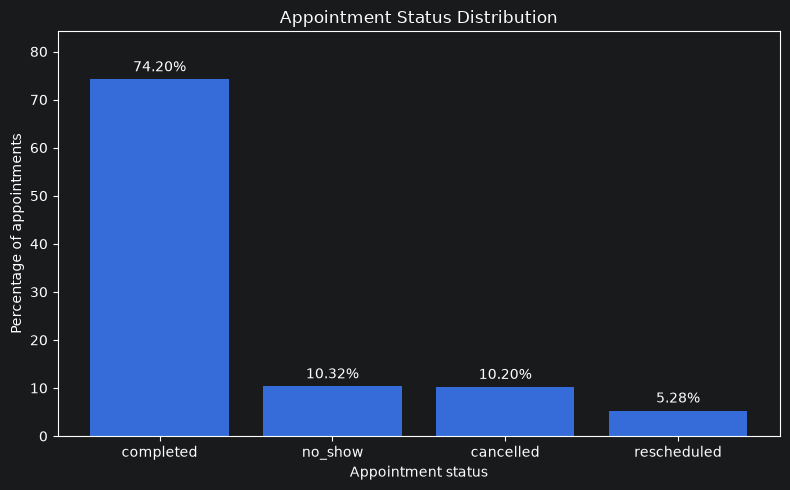

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    appointment_status_summary["status"],
    appointment_status_summary["appointment_percentage"],
)

ax.set_title("Appointment Status Distribution")
ax.set_xlabel("Appointment status")
ax.set_ylabel("Percentage of appointments")
ax.set_ylim(
    0,
    appointment_status_summary[
        "appointment_percentage"
    ].max() + 10,
)

for bar, percentage in zip(
    bars,
    appointment_status_summary[
        "appointment_percentage"
    ],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [18]:
reminder_no_show_summary = (
    appointments.assign(
        reminder_group=appointments[
            "reminder_sent"
        ].map(
            {
                True: "reminder_sent",
                False: "no_reminder",
            }
        )
    )
    .groupby(
        "reminder_group",
        as_index=False,
    )
    .agg(
        total_appointments=(
            "appointment_id",
            "count",
        ),
        no_show_count=(
            "status",
            lambda values: values.eq(
                "no_show"
            ).sum(),
        ),
    )
)

reminder_no_show_summary[
    "no_show_rate_percentage"
] = (
    100
    * reminder_no_show_summary[
        "no_show_count"
    ]
    / reminder_no_show_summary[
        "total_appointments"
    ]
).round(2)

reminder_no_show_summary = (
    reminder_no_show_summary.sort_values(
        "no_show_rate_percentage"
    ).reset_index(drop=True)
)

reminder_no_show_summary

,reminder_group,total_appointments,no_show_count,no_show_rate_percentage
0,reminder_sent,6616,578,8.74
1,no_reminder,1384,248,17.92


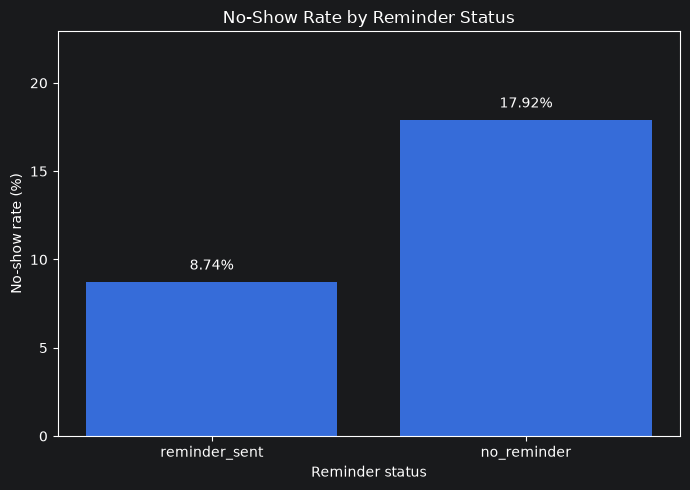

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    reminder_no_show_summary["reminder_group"],
    reminder_no_show_summary["no_show_rate_percentage"],
)

ax.set_title("No-Show Rate by Reminder Status")
ax.set_xlabel("Reminder status")
ax.set_ylabel("No-show rate (%)")
ax.set_ylim(
    0,
    reminder_no_show_summary[
        "no_show_rate_percentage"
    ].max() + 5,
)

for bar, percentage in zip(
    bars,
    reminder_no_show_summary[
        "no_show_rate_percentage"
    ],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [21]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_capacity_summary = (
    appointments.assign(
        weekday=appointments[
            "scheduled_start_at"
        ].dt.day_name(),
        unused_slot=appointments[
            "status"
        ].ne("completed"),
    )
    .groupby("weekday")
    .agg(
        total_appointments=(
            "appointment_id",
            "count",
        ),
        completed_appointments=(
            "unused_slot",
            lambda values: (~values).sum(),
        ),
        unused_slots=(
            "unused_slot",
            "sum",
        ),
    )
    .reindex(
        weekday_order,
        fill_value=0,
    )
    .reset_index()
)

total_appointments = weekday_capacity_summary[
    "total_appointments"
].astype(float)

total_appointments = total_appointments.replace(
    0,
    float("nan"),
)

weekday_capacity_summary[
    "unused_capacity_rate_percentage"
] = (
    100
    * weekday_capacity_summary["unused_slots"]
    / total_appointments
).round(2)

weekday_capacity_summary

,weekday,total_appointments,completed_appointments,unused_slots,unused_capacity_rate_percentage
0,Monday,1396,1022,374,26.79
1,Tuesday,1352,998,354,26.18
2,Wednesday,1338,1015,323,24.14
3,Thursday,1322,983,339,25.64
4,Friday,0,0,0,NaN
5,Saturday,1285,959,326,25.37
6,Sunday,1307,959,348,26.63


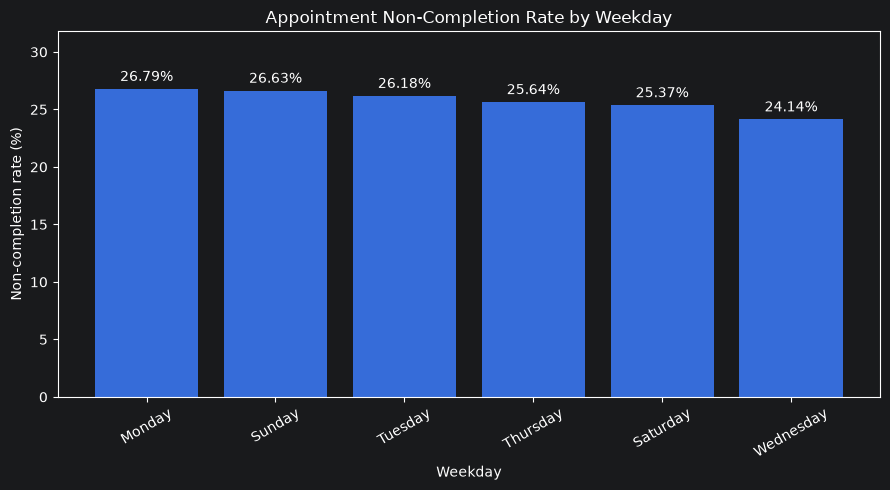

In [22]:
weekday_plot_data = (
    weekday_capacity_summary.loc[
        weekday_capacity_summary[
            "total_appointments"
        ] > 0
    ]
    .sort_values(
        "unused_capacity_rate_percentage",
        ascending=False,
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    weekday_plot_data["weekday"],
    weekday_plot_data[
        "unused_capacity_rate_percentage"
    ],
)

ax.set_title(
    "Appointment Non-Completion Rate by Weekday"
)
ax.set_xlabel("Weekday")
ax.set_ylabel("Non-completion rate (%)")
ax.set_ylim(
    0,
    weekday_plot_data[
        "unused_capacity_rate_percentage"
    ].max() + 5,
)

for bar, percentage in zip(
    bars,
    weekday_plot_data[
        "unused_capacity_rate_percentage"
    ],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
    )

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [23]:
procedure_completion_summary = (
    appointment_procedures[
        "completion_status"
    ]
    .value_counts(dropna=False)
    .rename_axis("completion_status")
    .reset_index(name="procedure_count")
)

procedure_completion_summary[
    "procedure_percentage"
] = (
    100
    * procedure_completion_summary[
        "procedure_count"
    ]
    / len(appointment_procedures)
).round(2)

procedure_completion_summary

,completion_status,procedure_count,procedure_percentage
0,completed,8041,95.98
1,partially_completed,256,3.06
2,discontinued,81,0.97


In [24]:
procedure_financials_by_status = (
    appointment_procedures
    .groupby(
        "completion_status",
        as_index=False,
    )
    .agg(
        procedure_count=(
            "appointment_procedure_id",
            "count",
        ),
        gross_fee_amount=(
            "fee_amount",
            "sum",
        ),
        discount_amount=(
            "discount_amount",
            "sum",
        ),
        direct_cost=(
            "direct_cost",
            "sum",
        ),
    )
)

procedure_financials_by_status[
    "net_revenue"
] = (
    procedure_financials_by_status[
        "gross_fee_amount"
    ]
    - procedure_financials_by_status[
        "discount_amount"
    ]
)

procedure_financials_by_status[
    [
        "gross_fee_amount",
        "discount_amount",
        "direct_cost",
        "net_revenue",
    ]
] = procedure_financials_by_status[
    [
        "gross_fee_amount",
        "discount_amount",
        "direct_cost",
        "net_revenue",
    ]
].round(2)

procedure_financials_by_status

,completion_status,procedure_count,gross_fee_amount,discount_amount,direct_cost,net_revenue
0,completed,8041,781805.96,20446.12,210255.96,761359.84
1,discontinued,81,1864.51,55.51,498.30,1809.00
2,partially_completed,256,13881.53,427.14,3527.02,13454.39


In [25]:
procedure_appointment_checks = (
    appointment_procedures[
        [
            "appointment_procedure_id",
            "appointment_id",
        ]
    ]
    .merge(
        appointments[
            [
                "appointment_id",
                "status",
                "chair_start_at",
                "chair_end_at",
            ]
        ],
        on="appointment_id",
        how="left",
        validate="many_to_one",
    )
)

procedure_appointment_checks[
    "actual_chair_minutes"
] = (
    procedure_appointment_checks[
        "chair_end_at"
    ]
    - procedure_appointment_checks[
        "chair_start_at"
    ]
).dt.total_seconds() / 60

procedure_linkage_summary = pd.Series(
    {
        "procedure_records": len(
            procedure_appointment_checks
        ),
        "missing_appointments": int(
            procedure_appointment_checks[
                "status"
            ].isna().sum()
        ),
        "procedures_on_non_completed_appointments": int(
            procedure_appointment_checks[
                "status"
            ].ne("completed").sum()
        ),
        "missing_chair_minutes": int(
            procedure_appointment_checks[
                "actual_chair_minutes"
            ].isna().sum()
        ),
        "zero_or_negative_chair_minutes": int(
            procedure_appointment_checks[
                "actual_chair_minutes"
            ].le(0).sum()
        ),
    },
    name="count",
)

procedure_linkage_summary

procedure_records                           8378
missing_appointments                           0
procedures_on_non_completed_appointments       0
missing_chair_minutes                          0
zero_or_negative_chair_minutes                 0
Name: count, dtype: int64

In [26]:
procedure_analysis = (
    appointment_procedures
    .merge(
        procedure_catalog[
            [
                "procedure_code",
                "procedure_group",
                "default_planned_duration_min",
            ]
        ],
        on="procedure_code",
        how="left",
        validate="many_to_one",
    )
    .merge(
        appointments[
            [
                "appointment_id",
                "chair_start_at",
                "chair_end_at",
            ]
        ],
        on="appointment_id",
        how="left",
        validate="many_to_one",
    )
)

procedure_analysis["actual_chair_minutes"] = (
    procedure_analysis["chair_end_at"]
    - procedure_analysis["chair_start_at"]
).dt.total_seconds() / 60

procedure_analysis["duration_weight"] = (
    procedure_analysis[
        "default_planned_duration_min"
    ]
    * procedure_analysis["quantity"]
)

procedure_analysis[
    "appointment_total_duration_weight"
] = (
    procedure_analysis
    .groupby("appointment_id")[
        "duration_weight"
    ]
    .transform("sum")
)

procedure_analysis["allocated_chair_minutes"] = (
    procedure_analysis["actual_chair_minutes"]
    * procedure_analysis["duration_weight"]
    / procedure_analysis[
        "appointment_total_duration_weight"
    ]
)

procedure_analysis["net_revenue"] = (
    procedure_analysis["fee_amount"]
    - procedure_analysis["discount_amount"]
)

procedure_analysis["direct_margin"] = (
    procedure_analysis["net_revenue"]
    - procedure_analysis["direct_cost"]
)

procedure_time_allocation_checks = pd.Series(
    {
        "procedure_records": len(
            procedure_analysis
        ),
        "missing_procedure_groups": int(
            procedure_analysis[
                "procedure_group"
            ].isna().sum()
        ),
        "missing_standard_durations": int(
            procedure_analysis[
                "default_planned_duration_min"
            ].isna().sum()
        ),
        "zero_or_negative_duration_weights": int(
            procedure_analysis[
                "duration_weight"
            ].le(0).sum()
        ),
        "missing_allocated_chair_minutes": int(
            procedure_analysis[
                "allocated_chair_minutes"
            ].isna().sum()
        ),
        "allocation_difference_minutes": round(
            procedure_analysis[
                "allocated_chair_minutes"
            ].sum()
            - procedure_analysis
            .drop_duplicates("appointment_id")[
                "actual_chair_minutes"
            ]
            .sum(),
            6,
        ),
    },
    name="value",
)

procedure_time_allocation_checks

procedure_records                    8378.0
missing_procedure_groups                0.0
missing_standard_durations              0.0
zero_or_negative_duration_weights       0.0
missing_allocated_chair_minutes         0.0
allocation_difference_minutes           0.0
Name: value, dtype: float64

In [27]:
procedure_group_performance = (
    procedure_analysis
    .groupby(
        "procedure_group",
        as_index=False,
    )
    .agg(
        procedure_count=(
            "appointment_procedure_id",
            "count",
        ),
        appointment_count=(
            "appointment_id",
            "nunique",
        ),
        allocated_chair_minutes=(
            "allocated_chair_minutes",
            "sum",
        ),
        gross_fee_amount=(
            "fee_amount",
            "sum",
        ),
        discount_amount=(
            "discount_amount",
            "sum",
        ),
        net_revenue=(
            "net_revenue",
            "sum",
        ),
        direct_cost=(
            "direct_cost",
            "sum",
        ),
        direct_margin=(
            "direct_margin",
            "sum",
        ),
    )
)

procedure_group_performance[
    "allocated_chair_hours"
] = (
    procedure_group_performance[
        "allocated_chair_minutes"
    ]
    / 60
)

procedure_group_performance[
    "net_revenue_per_chair_hour"
] = (
    procedure_group_performance[
        "net_revenue"
    ]
    / procedure_group_performance[
        "allocated_chair_hours"
    ]
)

procedure_group_performance[
    "direct_margin_per_chair_hour"
] = (
    procedure_group_performance[
        "direct_margin"
    ]
    / procedure_group_performance[
        "allocated_chair_hours"
    ]
)

procedure_group_performance[
    "direct_margin_percentage"
] = (
    100
    * procedure_group_performance[
        "direct_margin"
    ]
    / procedure_group_performance[
        "net_revenue"
    ]
)

procedure_group_performance = (
    procedure_group_performance
    .sort_values(
        "net_revenue_per_chair_hour",
        ascending=False,
    )
    .reset_index(drop=True)
)

numeric_columns = [
    "allocated_chair_minutes",
    "allocated_chair_hours",
    "gross_fee_amount",
    "discount_amount",
    "net_revenue",
    "direct_cost",
    "direct_margin",
    "net_revenue_per_chair_hour",
    "direct_margin_per_chair_hour",
    "direct_margin_percentage",
]

procedure_group_performance[
    numeric_columns
] = procedure_group_performance[
    numeric_columns
].round(2)

procedure_group_performance[
    [
        "procedure_group",
        "procedure_count",
        "appointment_count",
        "allocated_chair_hours",
        "net_revenue",
        "net_revenue_per_chair_hour",
        "direct_margin",
        "direct_margin_per_chair_hour",
        "direct_margin_percentage",
    ]
]

,procedure_group,procedure_count,appointment_count,allocated_chair_hours,net_revenue,net_revenue_per_chair_hour,direct_margin,direct_margin_per_chair_hour,direct_margin_percentage
0,prosthodontic,303,278,262.08,224241.39,855.63,126732.49,483.57,56.52
1,endodontic,791,739,656.11,205252.14,312.83,157867.50,240.61,76.91
2,surgical,463,428,366.13,66987.56,182.96,50591.71,138.18,75.52
3,restorative,829,802,656.54,86317.03,131.47,64064.89,97.58,74.22
4,periodontal,59,56,51.69,6051.92,117.07,4297.29,83.13,71.01
5,orthodontic,316,316,256.38,24026.27,93.72,19812.19,77.28,82.46
6,preventive,924,909,483.12,42813.04,88.62,33276.56,68.88,77.73
7,diagnostic,4693,3817,1860.78,120933.88,64.99,105699.32,56.80,87.40


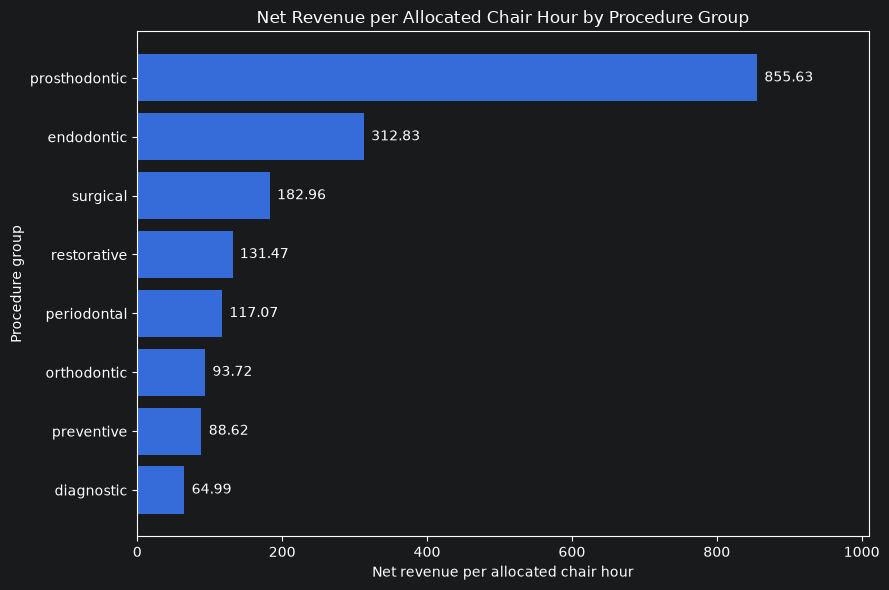

In [28]:
procedure_group_plot_data = (
    procedure_group_performance
    .sort_values(
        "net_revenue_per_chair_hour",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    procedure_group_plot_data[
        "procedure_group"
    ],
    procedure_group_plot_data[
        "net_revenue_per_chair_hour"
    ],
)

ax.set_title(
    "Net Revenue per Allocated Chair Hour by Procedure Group"
)
ax.set_xlabel("Net revenue per allocated chair hour")
ax.set_ylabel("Procedure group")

for bar, value in zip(
    bars,
    procedure_group_plot_data[
        "net_revenue_per_chair_hour"
    ],
):
    ax.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.2f}",
        va="center",
    )

ax.set_xlim(
    0,
    procedure_group_plot_data[
        "net_revenue_per_chair_hour"
    ].max() * 1.18,
)

plt.tight_layout()
plt.show()

In [29]:
plan_status_summary = (
    treatment_plans["plan_status"]
    .value_counts(dropna=False)
    .rename_axis("plan_status")
    .reset_index(name="plan_count")
)

plan_status_summary["plan_percentage"] = (
    100
    * plan_status_summary["plan_count"]
    / len(treatment_plans)
).round(2)

item_decision_summary = (
    treatment_plan_items["decision_status"]
    .value_counts(dropna=False)
    .rename_axis("decision_status")
    .reset_index(name="item_count")
)

item_decision_summary["item_percentage"] = (
    100
    * item_decision_summary["item_count"]
    / len(treatment_plan_items)
).round(2)

display(plan_status_summary)
display(item_decision_summary)

,plan_status,plan_count,plan_percentage
0,fully_accepted,827,46.59
1,partially_accepted,354,19.94
2,declined,266,14.99
3,presented,237,13.35
4,expired,91,5.13


,decision_status,item_count,item_percentage
0,accepted,2001,55.65
1,declined,797,22.16
2,pending,635,17.66
3,deferred,163,4.53


In [30]:
treatment_item_patient_data = (
    treatment_plan_items
    .merge(
        treatment_plans[
            [
                "plan_id",
                "patient_id",
            ]
        ],
        on="plan_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        patients[
            [
                "patient_id",
                "insurance_type",
            ]
        ],
        on="patient_id",
        how="left",
        validate="many_to_one",
    )
)

treatment_acceptance_checks = pd.Series(
    {
        "treatment_plan_items": len(
            treatment_item_patient_data
        ),
        "missing_patient_ids": int(
            treatment_item_patient_data[
                "patient_id"
            ].isna().sum()
        ),
        "missing_insurance_types": int(
            treatment_item_patient_data[
                "insurance_type"
            ].isna().sum()
        ),
        "accepted_items": int(
            treatment_item_patient_data[
                "decision_status"
            ].eq("accepted").sum()
        ),
        "declined_items": int(
            treatment_item_patient_data[
                "decision_status"
            ].eq("declined").sum()
        ),
        "pending_items": int(
            treatment_item_patient_data[
                "decision_status"
            ].eq("pending").sum()
        ),
        "deferred_items": int(
            treatment_item_patient_data[
                "decision_status"
            ].eq("deferred").sum()
        ),
    },
    name="count",
)

treatment_acceptance_checks

treatment_plan_items       3596
missing_patient_ids           0
missing_insurance_types       0
accepted_items             2001
declined_items              797
pending_items               635
deferred_items              163
Name: count, dtype: int64

In [32]:
insurance_acceptance_summary = (
    treatment_item_patient_data
    .assign(
        is_accepted=lambda dataframe: (
            dataframe["decision_status"].eq("accepted")
        ),
        is_declined=lambda dataframe: (
            dataframe["decision_status"].eq("declined")
        ),
        is_pending=lambda dataframe: (
            dataframe["decision_status"].eq("pending")
        ),
        is_deferred=lambda dataframe: (
            dataframe["decision_status"].eq("deferred")
        ),
    )
    .groupby(
        "insurance_type",
        as_index=False,
    )
    .agg(
        total_items=(
            "plan_item_id",
            "count",
        ),
        accepted_items=(
            "is_accepted",
            "sum",
        ),
        declined_items=(
            "is_declined",
            "sum",
        ),
        pending_items=(
            "is_pending",
            "sum",
        ),
        deferred_items=(
            "is_deferred",
            "sum",
        ),
    )
)

insurance_acceptance_summary[
    "decided_items"
] = (
    insurance_acceptance_summary["total_items"]
    - insurance_acceptance_summary["pending_items"]
)

insurance_acceptance_summary[
    "acceptance_rate_all_items"
] = (
    100
    * insurance_acceptance_summary["accepted_items"]
    / insurance_acceptance_summary["total_items"]
).round(2)

insurance_acceptance_summary[
    "acceptance_rate_decided_items"
] = (
    100
    * insurance_acceptance_summary["accepted_items"]
    / insurance_acceptance_summary["decided_items"]
).round(2)

insurance_acceptance_summary = (
    insurance_acceptance_summary
    .sort_values(
        "acceptance_rate_decided_items",
        ascending=False,
    )
    .reset_index(drop=True)
)

insurance_acceptance_summary[
    [
        "insurance_type",
        "total_items",
        "accepted_items",
        "pending_items",
        "decided_items",
        "acceptance_rate_all_items",
        "acceptance_rate_decided_items",
    ]
]

,insurance_type,total_items,accepted_items,pending_items,decided_items,acceptance_rate_all_items,acceptance_rate_decided_items
0,mixed,689,396,115,574,57.47,68.99
1,self_pay,1382,774,248,1134,56.01,68.25
2,basic_insurance,1024,548,199,825,53.52,66.42
3,supplementary_insurance,501,283,73,428,56.49,66.12


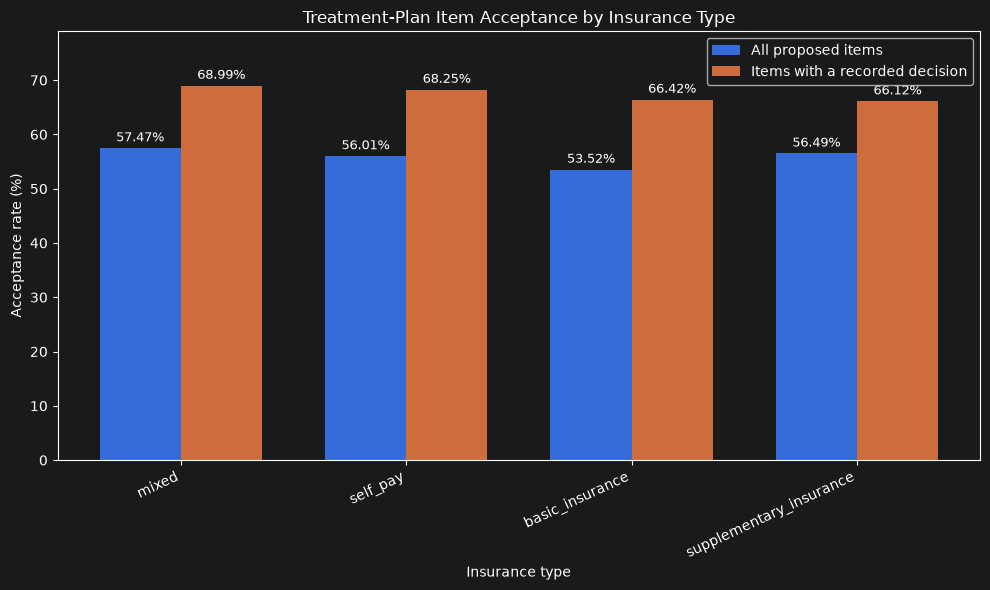

In [33]:
insurance_plot_data = (
    insurance_acceptance_summary
    .sort_values(
        "acceptance_rate_decided_items",
        ascending=False,
    )
    .reset_index(drop=True)
)

x_positions = list(
    range(len(insurance_plot_data))
)

bar_width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))

all_items_bars = ax.bar(
    [
        position - bar_width / 2
        for position in x_positions
    ],
    insurance_plot_data[
        "acceptance_rate_all_items"
    ],
    width=bar_width,
    label="All proposed items",
)

decided_items_bars = ax.bar(
    [
        position + bar_width / 2
        for position in x_positions
    ],
    insurance_plot_data[
        "acceptance_rate_decided_items"
    ],
    width=bar_width,
    label="Items with a recorded decision",
)

ax.set_title(
    "Treatment-Plan Item Acceptance by Insurance Type"
)
ax.set_xlabel("Insurance type")
ax.set_ylabel("Acceptance rate (%)")

ax.set_xticks(x_positions)
ax.set_xticklabels(
    insurance_plot_data["insurance_type"],
    rotation=25,
    ha="right",
)

ax.set_ylim(
    0,
    insurance_plot_data[
        "acceptance_rate_decided_items"
    ].max() + 10,
)

ax.legend()

for bars in [
    all_items_bars,
    decided_items_bars,
]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.7,
            f"{bar.get_height():.2f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

## 3. Findings, operational implications, and limitations

### 3.1 Appointment outcomes

**Finding:**
Of the 8,000 synthetic appointments, 74.20% were completed, 10.32% resulted in a no-show, 10.20% were cancelled, and 5.28% were rescheduled. In total, 25.80% of appointments did not reach completion.

**Possible operational action:**
Clinic management could investigate the causes of no-shows, cancellations, and rescheduling separately and design targeted interventions for each outcome.

**Limitation:**
The outcome probabilities were introduced by the synthetic data generator and do not represent the performance of a real dental clinic.

### 3.2 Appointment reminders and no-shows

**Finding:**
The synthetic no-show rate was 8.74% among appointments with a reminder, compared with 17.92% among appointments without a reminder.

**Possible operational action:**
A clinic could prioritize reliable reminder delivery and test whether reminder timing, communication channel, or message content influences attendance.

**Limitation:**
This is an observational association in synthetic data. It does not establish that reminders caused the lower no-show rate.

### 3.3 Appointment non-completion by weekday

**Finding:**
Among weekdays with scheduled appointments, non-completion rates ranged from 24.14% on Wednesday to 26.79% on Monday. The differences between weekdays were relatively small. No appointments were scheduled on Friday.

**Possible operational action:**
Management could monitor Monday appointments more closely, while also examining patient characteristics, booking lead time, appointment type, and reminder status before changing staffing or scheduling policies.

**Limitation:**
The analysis measures appointment non-completion, not true unused clinic capacity. Available working hours and unbooked appointment slots are not included in the dataset.

### 3.4 Revenue per allocated chair hour

**Finding:**
Prosthodontic procedures generated the highest synthetic net revenue per allocated chair hour at 855.63, followed by endodontic procedures at 312.83 and surgical procedures at 182.96.

**Possible operational action:**
Management could use this metric alongside demand, clinical capacity, direct margin, case complexity, and patient needs when evaluating the clinic’s service mix.

**Limitation:**
Actual chair time was allocated across procedures using standard-duration weights. The dataset does not record the exact time spent on each individual procedure. The values are synthetic and should not be interpreted as market prices or expected real-clinic profitability.

### 3.5 Treatment-plan item acceptance by insurance type

**Finding:**
Acceptance rates among items with a recorded decision ranged from 66.12% for supplementary insurance to 68.99% for mixed coverage. The difference between the highest and lowest groups was only 2.87 percentage points.

When pending items were included in the denominator, acceptance rates were lower, ranging from 53.52% to 57.47%.

**Possible operational action:**
Rather than treating insurance type as the main explanation for acceptance, management could investigate treatment value, procedure group, payment arrangement, patient history, and time between proposal and decision.

**Limitation:**
The observed differences are small and arise from synthetic data. No statistical or causal conclusion should be drawn from these group comparisons.

## 4. Overall interpretation

The current exploratory analysis suggests that appointment attendance, procedure economics, and treatment-plan conversion can be investigated through the integrated data model.

The most visible synthetic patterns are:

- A substantial share of appointments does not reach completion.
- Reminder status is strongly associated with the no-show rate.
- Weekday differences in non-completion are limited.
- Revenue per allocated chair hour varies considerably across procedure groups.
- Treatment-plan acceptance differs only modestly across insurance categories.

These results demonstrate the analytical workflow, but they should not be generalized to real clinics without validation using real operational data.